# MobileNetV2 Vegetable Classification V3 — video frames + Unknown class + color-jitter aug

Transfer-learn MobileNetV2 on an **expanded** dataset: the HuggingFace base plus frames sampled from user-recorded videos in `../../data/videos/`. Video filename prefix encodes the class (`bellpaper_2.mp4` / `bellpeper_1.mp4` → Bellpepper, `cabbage_1.mp4` → Cabbage, `unknown_*.mp4` → Unknown).

Key differences from V2:
- **Cucumber dropped** — V3 trains on **10 classes**: 9 named veggies (Bellpepper, Broccoli, Cabbage, Carrot, Eggplant, Garlic, Onion, Potato, Tomato) plus **Unknown** for non-target objects (red apples / strawberries / pomegranates, purple beetroot, cups, hands, etc.).
- **Cell 2b** extracts ~30 center-cropped frames per video into the **train** split of `mnv2_dataset/`. Val split is untouched so evaluation stays honest.
- **Cell 2c** assembles the Unknown class: ~5 stills/class sampled from the 43 unused HuggingFace classes (same lighting/background as positive classes, kills the "color shortcut" by surfacing red/purple non-targets), plus optional supplements from `../../data/unknown/` and `unknown_*.mp4`.
- **Cell 4** adds color-breaking augmentation (`RandomHue`, `RandomSaturation`, occasional grayscale) on top of V2's geometric augmentation — forces the model to learn texture/shape over hue.
- **Cell 5** raises Dropout from 0.3 → 0.5.
- **Cell 7** switches the fine-tune optimizer to AdamW with weight decay for better generalization.

Exports INT8 TFLite for ESP32S3 and uint8 TFLite for SenseCraft / Grove Vision AI V2 (unchanged from V2).

In [1]:
# Cell 1: Install and Import
!pip install -q tensorflow matplotlib seaborn scikit-learn pillow opencv-python


In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Configuration
IMG_SIZE = 96                  # MobileNetV2 supports 96/128/160/192/224
ALPHA = 0.35                   # Width multiplier - 0.35 is the smallest pretrained variant
EPOCHS_HEAD = 20               # Phase 1: train classification head with frozen base
# Phase 2 disabled: on this dataset+aug it overfits and val plateaus.
# EarlyStopping(restore_best_weights=True) in Phase 1 already gives us the best
# generalising checkpoint; fine-tuning further just memorises train.
EPOCHS_FINETUNE = 0
BATCH_SIZE = 32
CONFIDENCE_THRESHOLD = 0.9
NUM_CLASSES = 10
FINE_TUNE_AT = 100             # Unfreeze layers from this index onwards in phase 2

# 9 named veggies + Unknown catch-all class for non-target objects.
SELECTED_CLASSES = [
    'Bellpepper', 'Broccoli', 'Cabbage', 'Carrot',
    'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato',
    'Unknown',
]

# Paths: data lives at veggie_classification/data/huggingface
BASE_DIR = Path('..') / '..' / 'data' / 'huggingface'
TRAIN_DIR = BASE_DIR / 'Train'
VAL_DIR = BASE_DIR / 'val'

# User-recorded videos (filename prefix encodes class). Frames get mixed into the train split only.
VIDEO_DIR = Path('..') / '..' / 'data' / 'videos'

# Optional supplementary stills for the Unknown class (cups, hands, packaging, etc.).
UNKNOWN_DIR = Path('..') / '..' / 'data' / 'unknown'

# Keras image_dataset_from_directory reads classes from a single folder - mirror YOLO layout
MNV2_DATASET = Path('mnv2_dataset')
RUN_DIR = Path('runs') / 'veggie_mnv2'
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f'TensorFlow: {tf.__version__}')
print(f'OpenCV: {cv2.__version__}')
print(f'GPU available: {bool(tf.config.list_physical_devices("GPU"))}')
print(f'Selected classes: {SELECTED_CLASSES}')

TensorFlow: 2.19.1
OpenCV: 4.11.0
GPU available: False
Selected classes: ['Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato', 'Unknown']


In [3]:
# Cell 2: Prepare dataset — copy 9 named veggie classes from HuggingFace into mnv2_dataset/.
# (The Unknown class is built separately by Cell 2c.)

NAMED_CLASSES = [c for c in SELECTED_CLASSES if c != 'Unknown']

for split, src_dir in [('train', TRAIN_DIR), ('val', VAL_DIR)]:
    for cls in NAMED_CLASSES:
        dst = MNV2_DATASET / split / cls
        src = src_dir / cls
        if dst.is_symlink():
            dst.unlink()
        if dst.exists():
            continue
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copytree(src, dst)
        print(f'Copied: {src} -> {dst}')

# Clean any stray cache folders that image_dataset_from_directory would pick up as classes.
# Note: Unknown is in SELECTED_CLASSES so it's preserved; Cell 2c populates it.
for split in ['train', 'val']:
    split_dir = MNV2_DATASET / split
    for entry in split_dir.iterdir():
        if entry.name not in SELECTED_CLASSES:
            print(f'Removing non-class entry: {entry}')
            if entry.is_dir():
                shutil.rmtree(entry)
            else:
                entry.unlink()

print('\n=== Dataset Summary ===')
for split in ['train', 'val']:
    split_dir = MNV2_DATASET / split
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(list((split_dir / cls).glob('*')))
        total += count
        print(f'  {split}/{cls}: {count} images')
    print(f'  Total {split}: {total}\n')



=== Dataset Summary ===
  train/Bellpepper: 150 images
  train/Broccoli: 80 images
  train/Cabbage: 152 images
  train/Carrot: 112 images
  train/Eggplant: 114 images
  train/Garlic: 92 images
  train/Onion: 94 images
  train/Potato: 77 images
  train/Tomato: 122 images
  train/Unknown: 152 images
  Total train: 1145

  val/Bellpepper: 9 images
  val/Broccoli: 17 images
  val/Cabbage: 10 images
  val/Carrot: 9 images
  val/Eggplant: 10 images
  val/Garlic: 10 images
  val/Onion: 10 images
  val/Potato: 10 images
  val/Tomato: 10 images
  val/Unknown: 57 images
  Total val: 152



In [4]:
# Cell 2c: assemble the Unknown class.
#   Source A (primary): N stills/class from HuggingFace classes NOT in our 9 named ones.
#                       Same lighting/backgrounds as positives, so the model learns
#                       "this is not one of my 9", not "different background style".
#                       Specifically targets the reported failure modes — red things
#                       (Apple/Strawberry/Pomegranate/Chilli pepper/Raspberry) and
#                       purple things (Beetroot).
#   Source B (optional): all stills the user dropped into data/unknown/ (cups, hands,
#                        packaging, etc. — items the HF dataset doesn't cover).
# Cell 2b separately handles unknown_*.mp4 video frames.

UNKNOWN_PER_HF_CLASS_TRAIN = 5     # ~40 classes * 5 = ~200 train imgs
UNKNOWN_PER_HF_CLASS_VAL   = 1     # ~40 val imgs

# Aliases / dropped classes that must NOT be sampled into Unknown.
HF_EXCLUDE = set(NAMED_CLASSES) | {
    'Bell pepper', 'Capsicum',   # alt names for Bellpepper
    'Sweetcorn',                 # alias for Corn
    'Cucumber',                  # dropped in V3, but reserved (don't poison Unknown)
}

unknown_train = MNV2_DATASET / 'train' / 'Unknown'
unknown_val   = MNV2_DATASET / 'val'   / 'Unknown'
unknown_train.mkdir(parents=True, exist_ok=True)
unknown_val.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
n_hf_train = n_hf_val = 0
for split, src_root, n_per, dst in [
    ('train', TRAIN_DIR, UNKNOWN_PER_HF_CLASS_TRAIN, unknown_train),
    ('val',   VAL_DIR,   UNKNOWN_PER_HF_CLASS_VAL,   unknown_val),
]:
    if not src_root.exists():
        continue
    for cls_dir in sorted(src_root.iterdir()):
        if not cls_dir.is_dir() or cls_dir.name in HF_EXCLUDE:
            continue
        files = sorted(p for p in cls_dir.iterdir()
                       if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'})
        if not files:
            continue
        picks = rng.choice(files, size=min(n_per, len(files)), replace=False)
        for src in picks:
            dst_path = dst / f'{cls_dir.name}__{src.name}'
            if not dst_path.exists():
                shutil.copy(src, dst_path)
                if split == 'train':
                    n_hf_train += 1
                else:
                    n_hf_val += 1

print(f'Unknown from HuggingFace: {n_hf_train} train / {n_hf_val} val')

# # Source B — user-supplied stills (optional).
# n_user_train = n_user_val = 0
# if UNKNOWN_DIR.exists():
#     user_files = sorted(p for p in UNKNOWN_DIR.iterdir()
#                         if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'})
#     rng2 = np.random.default_rng(SEED + 1)
#     rng2.shuffle(user_files)
#     n_val_user = max(0, len(user_files) // 10)
#     for i, src in enumerate(user_files):
#         if i < n_val_user:
#             dst_path = unknown_val / f'user__{src.name}'
#             n_user_val += 1
#         else:
#             dst_path = unknown_train / f'user__{src.name}'
#             n_user_train += 1
#         if not dst_path.exists():
#             shutil.copy(src, dst_path)
#     print(f'Unknown from data/unknown/: {n_user_train} train / {n_user_val} val')
# else:
#     print(f'(No {UNKNOWN_DIR} — skipping user supplementary source)')

# --- Balance: cap Unknown train to the median positive class count ---
# Without this, mixing HF samples + user stills + videos can make Unknown
# 3-5x the size of any positive class, and the model collapses to "always
# predict Unknown" because that's the majority answer. Random downsample
# (seeded for reproducibility) keeps Unknown roughly the size of the LARGEST positive class
# (median was too aggressive — lost too much HF Unknown diversity). Val is left alone — extra Unknown val samples make the
# confusion matrix more informative without affecting training.
positive_train_counts = [
    len(list((MNV2_DATASET / 'train' / cls).glob('*')))
    for cls in NAMED_CLASSES
]
target_unknown_train = int(np.max(positive_train_counts))
unknown_files = sorted(unknown_train.glob('*'))
if len(unknown_files) > target_unknown_train:
    rng3 = np.random.default_rng(SEED + 2)
    drop_idx = set(rng3.choice(len(unknown_files),
                               size=len(unknown_files) - target_unknown_train,
                               replace=False).tolist())
    n_dropped = 0
    for i, f in enumerate(unknown_files):
        if i in drop_idx:
            f.unlink()
            n_dropped += 1
    print(f'Balanced Unknown train: capped at {target_unknown_train} '
          f'(median of positive classes); dropped {n_dropped} excess images.')
else:
    print(f'Unknown train ({len(unknown_files)}) already <= median positive '
          f'({target_unknown_train}); no rebalance needed.')

print(f'\nUnknown class total: '
      f'{len(list(unknown_train.glob("*")))} train / '
      f'{len(list(unknown_val.glob("*")))} val')

Unknown from HuggingFace: 62 train / 1 val
Balanced Unknown train: capped at 152 (median of positive classes); dropped 62 excess images.

Unknown class total: 152 train / 58 val


In [5]:
# Cell 2d: hard guarantee that every file in mnv2_dataset is decodable.
#
# Keras image_dataset_from_directory uses tf.io.decode_image, which accepts
# only JPEG / PNG / GIF / BMP via magic bytes. PIL is more permissive (it'll
# happily decode WebP or TIFF), so PIL-based filtering can let bad files
# through. This sweep uses tf.io.decode_image itself — anything that survives
# here will not crash training.
#
# Re-run this cell any time you see "Unknown image file format" during
# model.fit. It is idempotent: clean datasets pass through untouched.

import tensorflow as tf  # already imported above; re-imported for cell-level safety

def is_tf_decodable(path):
    try:
        tf.io.decode_image(tf.io.read_file(str(path)))
        return True
    except Exception:
        return False

removed = []
for f in MNV2_DATASET.rglob('*'):
    if not f.is_file():
        continue
    if not is_tf_decodable(f):
        removed.append(f)
        f.unlink()

print(f'Scanned mnv2_dataset/: removed {len(removed)} non-decodable files')
for f in removed:
    print(f'  - {f.relative_to(MNV2_DATASET)}')

print()
for split in ['train', 'val']:
    split_dir = MNV2_DATASET / split
    total = sum(len(list((split_dir / cls).glob('*'))) for cls in os.listdir(split_dir))
    print(f'  {split}: {total} files across {len(os.listdir(split_dir))} classes')

2026-05-12 11:10:09.186434: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:10:09.472432: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:10:12.272495: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:10:16.174438: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:10:17.258533: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:10:17.818733: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


Scanned mnv2_dataset/: removed 1 non-decodable files
  - val/Unknown/Cantaloupe__Cantaloupe_1.jpg

  train: 1145 files across 10 classes
  val: 152 files across 10 classes


In [6]:
# Cell 2b: Augment train set with frames sampled from user-recorded videos.
# Filename prefix encodes the class (handles typos bellpaper / bellpeper -> Bellpepper).
# Frames are written only into the TRAIN split so validation stays honest.

VIDEO_CLASS_MAP = {
    'bellpaper':  'Bellpepper',
    'bellpeper':  'Bellpepper',
    'bellpepper': 'Bellpepper',
    'broccoli':   'Broccoli',
    'cabbage':    'Cabbage',
    'carrot':     'Carrot',
    'eggplant':   'Eggplant',
    'garlic':     'Garlic',
    'onion':      'Onion',
    'potato':     'Potato',
    'tomato':     'Tomato',
    'unknown':    'Unknown',     # cups, hands, packaging, fridge interior, etc.
}
FRAMES_PER_VIDEO = 30          # roughly one frame per second for a 30s clip

def class_from_filename(name: str):
    stem = Path(name).stem.lower()
    prefix = stem.split('_', 1)[0]
    return VIDEO_CLASS_MAP.get(prefix)

def center_square_crop(frame):
    h, w = frame.shape[:2]
    side = min(h, w)
    y0, x0 = (h - side) // 2, (w - side) // 2
    return frame[y0:y0 + side, x0:x0 + side]

video_counts = {}
if not VIDEO_DIR.exists():
    print(f'No video dir at {VIDEO_DIR} - skipping video augmentation.')
else:
    for video_path in sorted(VIDEO_DIR.iterdir()):
        if video_path.suffix.lower() not in {'.mp4', '.mov', '.avi', '.mkv'}:
            continue
        cls = class_from_filename(video_path.name)
        if cls is None:
            print(f'[skip] unknown class for {video_path.name}')
            continue

        dst_dir = MNV2_DATASET / 'train' / cls
        dst_dir.mkdir(parents=True, exist_ok=True)

        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0:
            print(f'[skip] cannot read {video_path.name}')
            cap.release()
            continue

        step = max(1, total_frames // FRAMES_PER_VIDEO)
        saved = 0
        target = min(FRAMES_PER_VIDEO, total_frames)
        for i in range(target):
            frame_idx = min(i * step, total_frames - 1)
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ok, frame = cap.read()
            if not ok:
                continue
            frame = center_square_crop(frame)
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            out_path = dst_dir / f'{video_path.stem}_f{frame_idx:06d}.jpg'
            cv2.imwrite(str(out_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 92])
            saved += 1
        cap.release()

        video_counts[video_path.name] = (cls, saved)
        print(f'{video_path.name:30s} -> {cls:10s} ({saved} frames)')

print('\n=== Dataset after video augmentation ===')
for split in ['train', 'val']:
    split_dir = MNV2_DATASET / split
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(list((split_dir / cls).glob('*')))
        total += count
        print(f'  {split}/{cls}: {count} images')
    print(f'  Total {split}: {total}\n')


bellpaper_2.mp4                -> Bellpepper (30 frames)
bellpeper_1.mp4                -> Bellpepper (30 frames)
bellpepper_3.mp4               -> Bellpepper (30 frames)
broccoli_1.mp4                 -> Broccoli   (30 frames)
cabbage_1.mp4                  -> Cabbage    (30 frames)
cabbage_2.mp4                  -> Cabbage    (30 frames)
cabbage_3.mp4                  -> Cabbage    (30 frames)
carrot_1.mp4                   -> Carrot     (30 frames)
carrot_2.mp4                   -> Carrot     (30 frames)
[skip] unknown class for cucumber_1.mp4
eggplant_1.mp4                 -> Eggplant   (30 frames)
eggplant_2.mp4                 -> Eggplant   (30 frames)
onion_1.mp4                    -> Onion      (30 frames)
tomato_1.mp4                   -> Tomato     (30 frames)
tomato_2.mp4                   -> Tomato     (30 frames)

=== Dataset after video augmentation ===
  train/Bellpepper: 180 images
  train/Broccoli: 110 images
  train/Cabbage: 182 images
  train/Carrot: 142 images
  tra

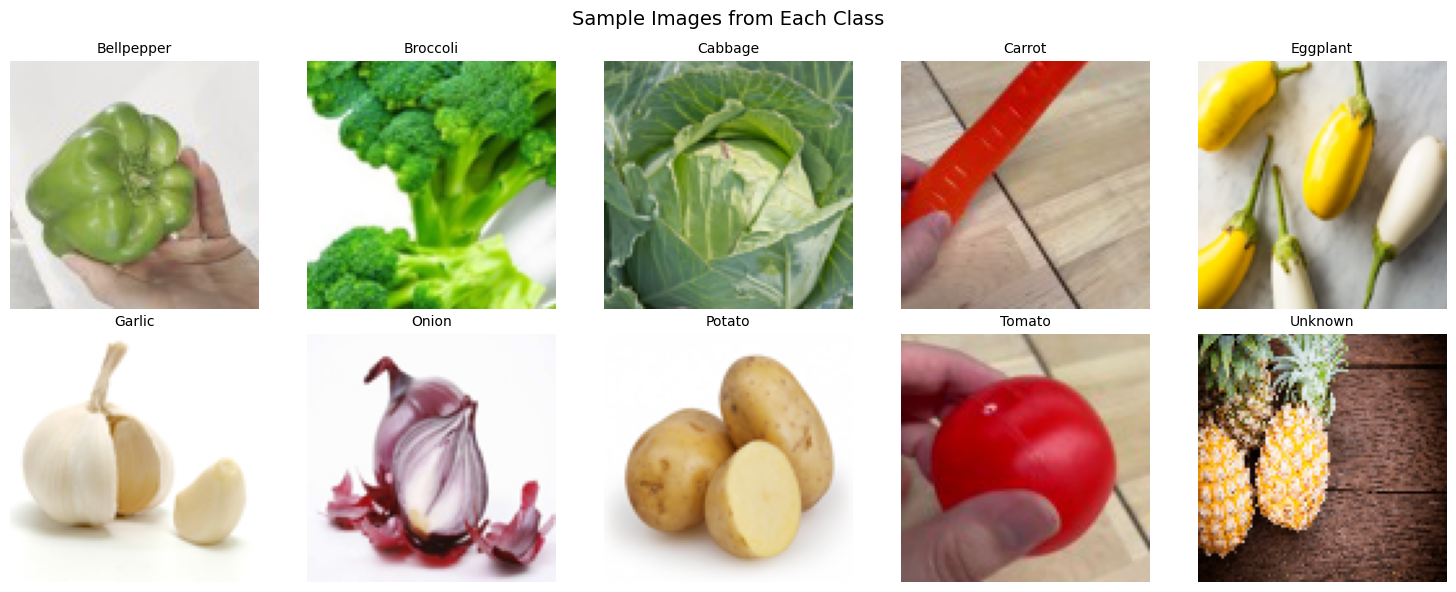

In [7]:
# Cell 3: Visualize sample images

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(SELECTED_CLASSES):
    ax = axes[i // 5, i % 5]
    cls_path = MNV2_DATASET / 'train' / cls
    img_path = list(cls_path.glob('*'))[0]
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Cell 4: Build tf.data pipelines with augmentation

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    MNV2_DATASET / 'train',
    labels='inferred',
    label_mode='int',
    class_names=SELECTED_CLASSES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    MNV2_DATASET / 'val',
    labels='inferred',
    label_mode='int',
    class_names=SELECTED_CLASSES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = list(train_ds_raw.class_names)
print(f'class_names: {class_names}')

# Geometric augmentation (V2 baseline) plus mild color jitter.
# Earlier ±8% hue / 0.7-1.3x saturation was too aggressive for this small
# dataset and smeared the Bellpepper/Tomato boundary (yellow pepper looking
# orange-tomato, red pepper looking pink-tomato). Tighter ranges still
# discourage exact-hue shortcuts without erasing the red-vs-green-vs-yellow
# distinction the model needs.
#
# RandomHue/RandomSaturation are missing from some Keras builds, so we wrap
# the canonical tf.image.* ops in a Lambda. tf.image.random_hue expects [0,1]
# floats, so we normalise / denormalise around the HSV roundtrip.
def random_hue_sat(x):
    x = tf.cast(x, tf.float32) / 255.0
    x = tf.image.random_hue(x, max_delta=0.03)            # was 0.08
    x = tf.image.random_saturation(x, lower=0.9, upper=1.1)  # was (0.7, 1.3)
    return tf.clip_by_value(x, 0.0, 1.0) * 255.0

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.25),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
    layers.Lambda(random_hue_sat, name='random_hue_sat'),
    # random_grayscale removed: combined with hue/sat shifts it was eroding
    # the very colour signal the model needs for confusable classes.
], name='data_augmentation')

AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, training):
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    # MobileNetV2 expects inputs scaled to [-1, 1]
    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds_raw, training=True)
val_ds = prepare(val_ds_raw, training=False)

for imgs, labels in train_ds.take(1):
    print(f'Batch shape: {imgs.shape}, range [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]')
    print(f'Labels: {labels.numpy()}')

Found 1355 files belonging to 10 classes.
Found 152 files belonging to 10 classes.
class_names: ['Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato', 'Unknown']


2026-05-12 11:12:47.210457: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:47.234370: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:47.310868: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Batch shape: (32, 96, 96, 3), range [-1.00, 1.00]
Labels: [7 7 2 6 8 4 2 3 2 8 2 5 4 5 6 3 0 2 8 5 2 9 9 3 5 8 9 1 8 2 1 4]


In [9]:
# Cell 5: Build MobileNetV2 transfer-learning model

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    alpha=ALPHA,
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input')
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
x = layers.Dropout(0.5, name='dropout')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

model = models.Model(inputs, outputs, name='mnv2_veggie')
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()


Model: "mnv2_veggie"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_96             │ (None, 3, 3, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,018 (1.61 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 410,208 (1.56 MB)

In [10]:
# Cell 6: Phase 1 - train classification head (base frozen)

ckpt_path = RUN_DIR / 'best_head.keras'
cb = [
    callbacks.ModelCheckpoint(str(ckpt_path), monitor='val_accuracy',
                              save_best_only=True, mode='max'),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                            mode='max', restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
]

# Class weights from current train file counts. Even after Cell 2c balancing,
# the positive classes still range ~77-152 (Potato vs Cabbage). Weighting the
# loss inversely to frequency makes each class contribute equally.
import collections
_counts = collections.Counter()
for _, lbls in train_ds_raw:
    for v in lbls.numpy().tolist():
        _counts[v] += 1
_total = sum(_counts.values())
class_weight = {i: _total / (NUM_CLASSES * max(_counts[i], 1))
                for i in range(NUM_CLASSES)}
print('class_weight:', {class_names[i]: f'{w:.2f}' for i, w in class_weight.items()})

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=cb,
    class_weight=class_weight,
    verbose=2,
)

2026-05-12 11:12:47.899252: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:47.947197: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:48.170628: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:48.289649: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:48.910948: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:49.243934: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


class_weight: {'Bellpepper': '0.75', 'Broccoli': '1.23', 'Cabbage': '0.74', 'Carrot': '0.95', 'Eggplant': '0.94', 'Garlic': '1.47', 'Onion': '1.09', 'Potato': '1.76', 'Tomato': '0.89', 'Unknown': '0.89'}
Epoch 1/20


2026-05-12 11:12:51.014308: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:51.248830: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:51.361390: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:51.486680: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:51.641137: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:12:52.789628: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


43/43 - 5s - 106ms/step - accuracy: 0.3151 - loss: 2.1439 - val_accuracy: 0.5526 - val_loss: 1.3163 - learning_rate: 1.0000e-03
Epoch 2/20
43/43 - 1s - 19ms/step - accuracy: 0.6096 - loss: 1.1228 - val_accuracy: 0.6579 - val_loss: 1.0241 - learning_rate: 1.0000e-03
Epoch 3/20
43/43 - 1s - 19ms/step - accuracy: 0.6930 - loss: 0.8716 - val_accuracy: 0.6974 - val_loss: 0.8889 - learning_rate: 1.0000e-03
Epoch 4/20
43/43 - 1s - 19ms/step - accuracy: 0.7380 - loss: 0.7265 - val_accuracy: 0.7105 - val_loss: 0.8289 - learning_rate: 1.0000e-03
Epoch 5/20
43/43 - 1s - 17ms/step - accuracy: 0.7823 - loss: 0.6275 - val_accuracy: 0.7105 - val_loss: 0.8231 - learning_rate: 1.0000e-03
Epoch 6/20
43/43 - 1s - 19ms/step - accuracy: 0.7993 - loss: 0.5513 - val_accuracy: 0.7434 - val_loss: 0.7741 - learning_rate: 1.0000e-03
Epoch 7/20
43/43 - 1s - 19ms/step - accuracy: 0.8059 - loss: 0.5344 - val_accuracy: 0.7697 - val_loss: 0.7396 - learning_rate: 1.0000e-03
Epoch 8/20
43/43 - 1s - 18ms/step - accuracy

In [11]:
# Cell 7: Phase 2 - fine-tune top layers of MobileNetV2

ckpt_path_ft   = RUN_DIR / 'best.keras'
ckpt_path_head = RUN_DIR / 'best_head.keras'

if EPOCHS_FINETUNE == 0:
    # Phase 2 disabled. EarlyStopping(restore_best_weights=True) in Phase 1
    # already left `model` with the best-val-acc weights in memory; copy
    # best_head.keras -> best.keras so downstream cells (eval, TFLite export,
    # header gen) consume Phase 1's checkpoint, not a stale Phase 2 file from
    # a prior run.
    print('Phase 2 disabled (EPOCHS_FINETUNE=0). Using Phase 1 best as final model.')
    if ckpt_path_head.exists():
        shutil.copy(ckpt_path_head, ckpt_path_ft)
    else:
        model.save(ckpt_path_ft)
    history_ft = type('H', (), {'history': {}})()   # empty placeholder for Cell 8 plotter
    print(f'Best model saved to: {ckpt_path_ft}')
else:
    base_model.trainable = True
    # Freeze everything before FINE_TUNE_AT, train the rest.
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False

    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f'Base layers total: {len(base_model.layers)}, trainable: {trainable_count}')

    # AdamW adds decoupled weight decay - better generalisation on a small
    # dataset where the train set is now inflated with correlated video frames.
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    cb_ft = [
        callbacks.ModelCheckpoint(str(ckpt_path_ft), monitor='val_accuracy',
                                  save_best_only=True, mode='max'),
        callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                mode='max', restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ]

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINETUNE,
        callbacks=cb_ft,
        verbose=2,
    )

    # If ModelCheckpoint never improved on the initial val_accuracy, the file
    # may not exist - fall back to saving current weights.
    if not ckpt_path_ft.exists():
        model.save(ckpt_path_ft)
    print(f'Best model saved to: {ckpt_path_ft}')

Phase 2 disabled (EPOCHS_FINETUNE=0). Using Phase 1 best as final model.
Best model saved to: runs/veggie_mnv2/best.keras


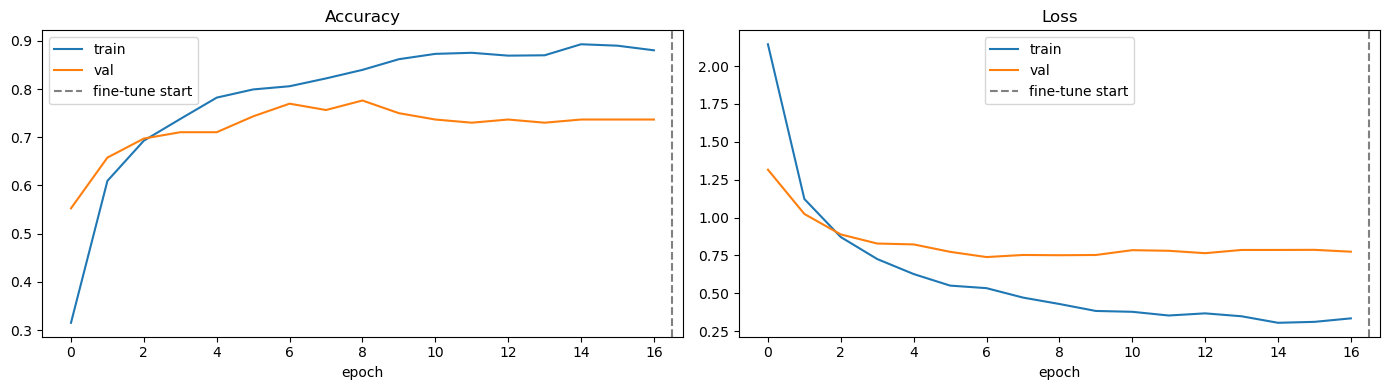

In [12]:
# Cell 8: Training curves

def merge(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc = merge(history_head, history_ft, 'accuracy')
val_acc = merge(history_head, history_ft, 'val_accuracy')
loss = merge(history_head, history_ft, 'loss')
val_loss = merge(history_head, history_ft, 'val_loss')
boundary = len(history_head.history.get('accuracy', []))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(acc, label='train')
axes[0].plot(val_acc, label='val')
axes[0].axvline(boundary - 0.5, color='gray', linestyle='--', label='fine-tune start')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(loss, label='train')
axes[1].plot(val_loss, label='val')
axes[1].axvline(boundary - 0.5, color='gray', linestyle='--', label='fine-tune start')
axes[1].set_title('Loss'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(RUN_DIR / 'training_curves.png', dpi=120)
plt.show()

In [13]:
# Cell 9: Evaluate on validation set

best_model = tf.keras.models.load_model(ckpt_path_ft)
val_loss_final, val_acc_final = best_model.evaluate(val_ds, verbose=0)
print(f'Top-1 Accuracy: {val_acc_final:.4f}')
print(f'Val Loss:       {val_loss_final:.4f}')

Top-1 Accuracy: 0.7763
Val Loss:       0.7517


Predictions below threshold (0.9): 94/152
These would be "Object not known"

=== Classification Report (confident predictions) ===
              precision    recall  f1-score   support

  Bellpepper       1.00      1.00      1.00         2
    Broccoli       1.00      1.00      1.00         6
     Cabbage       0.91      1.00      0.95        10
      Carrot       0.86      1.00      0.92         6
    Eggplant       0.88      1.00      0.93         7
      Garlic       0.88      1.00      0.93         7
       Onion       1.00      1.00      1.00         4
      Potato       1.00      1.00      1.00         7
      Tomato       1.00      1.00      1.00         1
     Unknown       1.00      0.50      0.67         8

    accuracy                           0.93        58
   macro avg       0.95      0.95      0.94        58
weighted avg       0.94      0.93      0.92        58

=== Classification Report (all predictions) ===
              precision    recall  f1-score   support

  Bellp

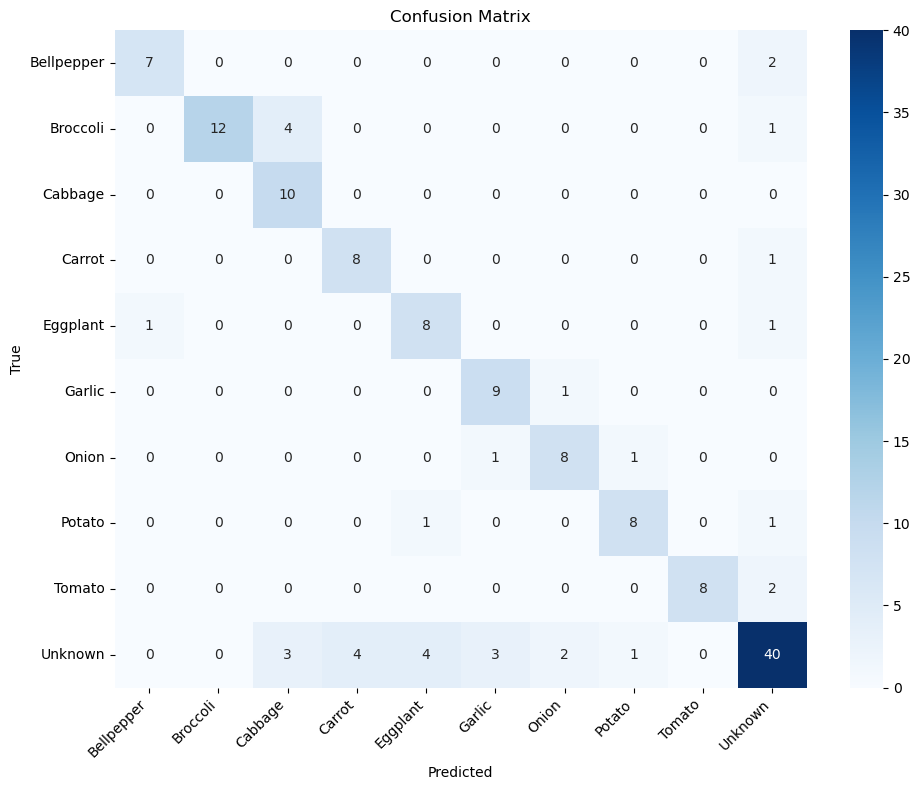

Overall accuracy: 0.7763


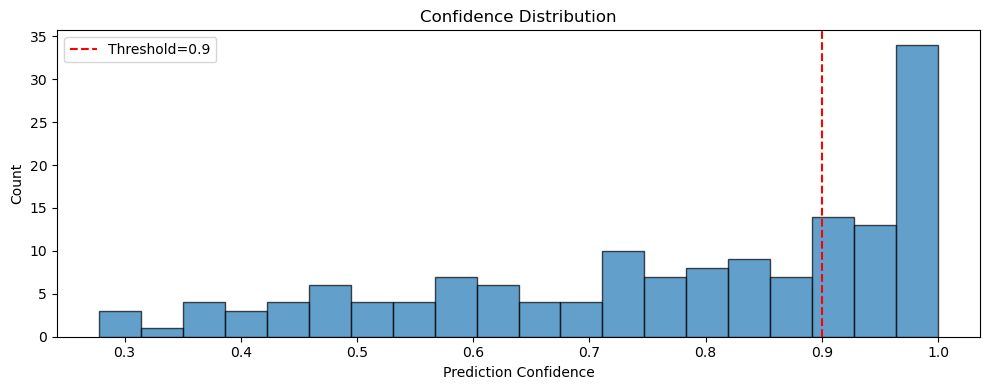

In [14]:
# Cell 10: Detailed per-class evaluation with confidence threshold

y_true, y_pred, y_conf = [], [], []
all_labels = list(range(len(class_names)))

for imgs, labels in val_ds:
    probs = best_model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_conf.extend(np.max(probs, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

unknown_mask = y_conf < CONFIDENCE_THRESHOLD
confident_mask = ~unknown_mask
print(f'Predictions below threshold ({CONFIDENCE_THRESHOLD}): {np.sum(unknown_mask)}/{len(y_true)}')
print('These would be "Object not known"\n')

if np.sum(confident_mask) > 0:
    print('=== Classification Report (confident predictions) ===')
    print(classification_report(
        y_true[confident_mask], y_pred[confident_mask],
        labels=all_labels, target_names=class_names, zero_division=0
    ))

print('=== Classification Report (all predictions) ===')
print(classification_report(
    y_true, y_pred,
    labels=all_labels, target_names=class_names, zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(RUN_DIR / 'confusion_matrix.png', dpi=120)
plt.show()

accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f'Overall accuracy: {accuracy:.4f}')

plt.figure(figsize=(10, 4))
plt.hist(y_conf, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=CONFIDENCE_THRESHOLD, color='r', linestyle='--',
            label=f'Threshold={CONFIDENCE_THRESHOLD}')
plt.xlabel('Prediction Confidence'); plt.ylabel('Count')
plt.title('Confidence Distribution'); plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / 'confidence_hist.png', dpi=120)
plt.show()

In [15]:
# Cell 11: Export to TFLite INT8

# Build a representative dataset for INT8 calibration. Feed RAW [0,255] images -
# we'll bake preprocess_input (scale to [-1,1]) into the exported model so the
# ESP32 firmware can pass uint8 camera pixels directly.
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    MNV2_DATASET / 'train',
    labels='inferred', label_mode='int',
    class_names=SELECTED_CLASSES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, shuffle=True, seed=SEED,
)

def representative_dataset():
    for i, (img, _) in enumerate(raw_train_ds.take(200)):
        yield [tf.cast(img, tf.float32)]

# Wrap: raw [0,255] input -> preprocess -> trained model
raw_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='raw_input')
scaled = layers.Lambda(lambda t: preprocess_input(tf.cast(t, tf.float32)),
                       name='preprocess')(raw_in)
logits = best_model(scaled)
export_model = models.Model(raw_in, logits, name='mnv2_veggie_export')

converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_bytes = converter.convert()

tflite_path = Path('veggie_mnv2.tflite')
tflite_path.write_bytes(tflite_bytes)

tflite_size = tflite_path.stat().st_size
print(f'TFLite model: {tflite_path}')
print(f'Size: {tflite_size / 1024:.1f} KB ({tflite_size / (1024*1024):.2f} MB)')
print(f'Fits in ESP32S3 8MB flash: {"YES" if tflite_size < 4 * 1024 * 1024 else "NO"}')

Found 1355 files belonging to 10 classes.
INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpm8fnxu7p/assets


INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpm8fnxu7p/assets


Saved artifact at '/var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpm8fnxu7p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='raw_input')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  14718222160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548519504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548519696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548523152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548523536: T

W0000 00:00:1778609592.408217 33413766 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778609592.408225 33413766 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778609592.473776 33413766 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-05-12 11:13:13.859939: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:13:14.104844: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:13:14.364536: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


TFLite model: veggie_mnv2.tflite
Size: 624.7 KB (0.61 MB)
Fits in ESP32S3 8MB flash: YES


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [16]:
# Cell 11b: Export a SenseCraft / Grove Vision AI V2 compatible TFLite (uint8 I/O)
# Separate artifact from veggie_mnv2.tflite - used only for SenseCraft upload.
# model_data.h / labels.h (Cell 13) keep using the int8 export above.

# Rescaling lowers to plain Mul+Add in TFLite, which Vela folds into the first
# Conv - no Cast op boundary (unlike the Lambda used in Cell 11).
raw_in_u8 = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='raw_input')
scaled_u8 = layers.Rescaling(scale=1.0/127.5, offset=-1.0, name='preprocess')(raw_in_u8)
logits_u8 = best_model(scaled_u8)
export_model_u8 = models.Model(raw_in_u8, logits_u8, name='mnv2_veggie_sensecraft')

conv_u8 = tf.lite.TFLiteConverter.from_keras_model(export_model_u8)
conv_u8.optimizations = [tf.lite.Optimize.DEFAULT]
conv_u8.representative_dataset = representative_dataset   # reuse: yields [0,255] float32
conv_u8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_u8.inference_input_type = tf.uint8
conv_u8.inference_output_type = tf.uint8

tflite_bytes_u8 = conv_u8.convert()
tflite_path_u8 = Path('veggie_mnv2_sensecraft.tflite')
tflite_path_u8.write_bytes(tflite_bytes_u8)

print(f'SenseCraft TFLite: {tflite_path_u8}')
print(f'Size: {tflite_path_u8.stat().st_size / 1024:.1f} KB')

# Sanity check: input MUST be uint8 for Grove Vision AI V2
itp = tf.lite.Interpreter(model_path=str(tflite_path_u8)); itp.allocate_tensors()
i, o = itp.get_input_details()[0], itp.get_output_details()[0]
print(f'Input:  shape={i["shape"]}, dtype={i["dtype"].__name__}, q={i["quantization"]}')
print(f'Output: shape={o["shape"]}, dtype={o["dtype"].__name__}, q={o["quantization"]}')
assert i['dtype'].__name__ == 'uint8', 'Expected uint8 input for SenseCraft upload'


INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpzlfwspw6/assets


INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpzlfwspw6/assets


Saved artifact at '/var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpzlfwspw6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='raw_input')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  14718222160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548519504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548519696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548523152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548523536: T

W0000 00:00:1778609597.392135 33413766 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778609597.392144 33413766 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-12 11:13:18.781738: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:13:18.868600: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:13:19.219247: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


SenseCraft TFLite: veggie_mnv2_sensecraft.tflite
Size: 626.0 KB
Input:  shape=[ 1 96 96  3], dtype=uint8, q=(1.0, 0)
Output: shape=[ 1 10], dtype=uint8, q=(0.00390625, 0)


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [17]:
# Cell 11c: Export int8-everywhere TFLite for Vela / Grove Vision AI V2 NPU
# Ethos-U55 requires int8 input/output (uint8 variants fall back to CPU or fail).
# Feed this file to ethos-u-vela to produce the _vela.tflite that SenseCraft uploads.

raw_in_i8 = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='raw_input')
scaled_i8 = layers.Rescaling(scale=1.0/127.5, offset=-1.0, name='preprocess')(raw_in_i8)
logits_i8 = best_model(scaled_i8)
export_model_i8 = models.Model(raw_in_i8, logits_i8, name='mnv2_veggie_vela')

conv_i8 = tf.lite.TFLiteConverter.from_keras_model(export_model_i8)
conv_i8.optimizations = [tf.lite.Optimize.DEFAULT]
conv_i8.representative_dataset = representative_dataset   # reuse: yields [0,255] float32
conv_i8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_i8.inference_input_type = tf.int8
conv_i8.inference_output_type = tf.int8

tflite_bytes_i8 = conv_i8.convert()
tflite_path_i8 = Path('veggie_mnv2_sensecraft_int8.tflite')
tflite_path_i8.write_bytes(tflite_bytes_i8)

print(f'Vela-ready TFLite: {tflite_path_i8}')
print(f'Size: {tflite_path_i8.stat().st_size / 1024:.1f} KB')

itp = tf.lite.Interpreter(model_path=str(tflite_path_i8)); itp.allocate_tensors()
i, o = itp.get_input_details()[0], itp.get_output_details()[0]
print(f'Input:  shape={i["shape"]}, dtype={i["dtype"].__name__}, q={i["quantization"]}')
print(f'Output: shape={o["shape"]}, dtype={o["dtype"].__name__}, q={o["quantization"]}')
assert i['dtype'].__name__ == 'int8' and o['dtype'].__name__ == 'int8', \
    'Vela requires int8 I/O'

print('\nNext step: run')
print(f'  python ../sensecraft/compile_vela.py {tflite_path_i8.resolve()}')


INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmp86dqgx8u/assets


INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmp86dqgx8u/assets


Saved artifact at '/var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmp86dqgx8u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='raw_input')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  14718222160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548519504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548520848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548519696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548523152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548522192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13548523536: T

W0000 00:00:1778609602.309161 33413766 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778609602.309179 33413766 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-12 11:13:23.743090: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:13:23.878135: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2026-05-12 11:13:24.246880: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


Vela-ready TFLite: veggie_mnv2_sensecraft_int8.tflite
Size: 624.2 KB
Input:  shape=[ 1 96 96  3], dtype=int8, q=(1.0, -128)
Output: shape=[ 1 10], dtype=int8, q=(0.00390625, -128)

Next step: run
  python ../sensecraft/compile_vela.py /Users/menglh/Desktop/GIX26Spring/SnapChef/veggie_classification/train/classification_V3/veggie_mnv2_sensecraft_int8.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [18]:
# Cell 12: Validate TFLite model

interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('=== TFLite Model Info ===')
print(f'Input:  shape={input_details[0]["shape"]}, dtype={input_details[0]["dtype"]}')
print(f'Output: shape={output_details[0]["shape"]}, dtype={output_details[0]["dtype"]}')

input_scale, input_zp = input_details[0]['quantization']
output_scale, output_zp = output_details[0]['quantization']
print(f'Input quantization:  scale={input_scale}, zero_point={input_zp}')
print(f'Output quantization: scale={output_scale}, zero_point={output_zp}')

tflite_preds, tflite_confs, tflite_true = [], [], []
input_dtype = input_details[0]['dtype']

for cls_idx, cls_name in enumerate(class_names):
    cls_dir = MNV2_DATASET / 'val' / cls_name
    for img_path in cls_dir.glob('*'):
        img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)  # raw [0,255]
        if input_dtype == np.int8:
            q = np.round(img_array / input_scale + input_zp).astype(np.int8)
        elif input_dtype == np.uint8:
            q = np.round(img_array / input_scale + input_zp).astype(np.uint8)
        else:
            q = img_array
        q = np.expand_dims(q, axis=0)
        interpreter.set_tensor(input_details[0]['index'], q)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]['index'])
        if output_details[0]['dtype'] in [np.int8, np.uint8]:
            out = (out.astype(np.float32) - output_zp) * output_scale
        if out.sum() < 0.5 or out.sum() > 1.5:
            e = np.exp(out - np.max(out)); out = e / e.sum()
        tflite_preds.append(int(np.argmax(out)))
        tflite_confs.append(float(np.max(out)))
        tflite_true.append(cls_idx)

tflite_preds = np.array(tflite_preds)
tflite_true = np.array(tflite_true)
tflite_accuracy = np.sum(tflite_preds == tflite_true) / len(tflite_true)

print(f'\n=== Accuracy Comparison ===')
print(f'Keras MobileNetV2 model: {accuracy:.4f}')
print(f'TFLite INT8 model:       {tflite_accuracy:.4f}')
print(f'Accuracy drop:           {(accuracy - tflite_accuracy) * 100:.2f}%')

=== TFLite Model Info ===
Input:  shape=[ 1 96 96  3], dtype=<class 'numpy.int8'>
Output: shape=[ 1 10], dtype=<class 'numpy.int8'>
Input quantization:  scale=1.0, zero_point=-128
Output quantization: scale=0.00390625, zero_point=-128

=== Accuracy Comparison ===
Keras MobileNetV2 model: 0.7763
TFLite INT8 model:       0.7171
Accuracy drop:           5.92%


In [19]:
# Cell 13: Export C header for ESP32

def export_c_header(tflite_path, header_path, array_name='model_data'):
    with open(tflite_path, 'rb') as f:
        data = f.read()
    with open(header_path, 'w') as f:
        f.write('#ifndef MODEL_DATA_H\n')
        f.write('#define MODEL_DATA_H\n\n')
        f.write(f'const unsigned int {array_name}_len = {len(data)};\n\n')
        f.write(f'alignas(16) const unsigned char {array_name}[] = {{\n')
        for i in range(0, len(data), 12):
            chunk = data[i:i+12]
            hex_vals = ', '.join(f'0x{b:02x}' for b in chunk)
            f.write(f'  {hex_vals},\n')
        f.write('};\n\n')
        f.write('#endif // MODEL_DATA_H\n')
    print(f'Model header: {header_path} ({len(data)} bytes)')

def export_labels_header(class_names, header_path, threshold=CONFIDENCE_THRESHOLD):
    with open(header_path, 'w') as f:
        f.write('#ifndef LABELS_H\n')
        f.write('#define LABELS_H\n\n')
        f.write(f'const int NUM_CLASSES = {len(class_names)};\n')
        f.write(f'const float CONFIDENCE_THRESHOLD = {threshold}f;\n')
        f.write('const char* UNKNOWN_LABEL = "Object not known";\n\n')
        f.write('const char* LABELS[] = {\n')
        for name in class_names:
            f.write(f'  "{name}",\n')
        f.write('};\n\n')
        f.write('#endif // LABELS_H\n')
    print(f'Labels header: {header_path}')

export_c_header(tflite_path, 'model_data.h')
export_labels_header(class_names, 'labels.h')

print(f'\n=== Final Summary ===')
print(f'Model: MobileNetV2 alpha={ALPHA}, {IMG_SIZE}x{IMG_SIZE}, INT8')
print(f'TFLite size: {tflite_size / 1024:.1f} KB ({tflite_size / (1024*1024):.2f} MB)')
print(f'Classes: {class_names}')
print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}')
print(f'\nCopy model_data.h and labels.h into esp32_deploy/ to update the firmware.')

Model header: model_data.h (639656 bytes)
Labels header: labels.h

=== Final Summary ===
Model: MobileNetV2 alpha=0.35, 96x96, INT8
TFLite size: 624.7 KB (0.61 MB)
Classes: ['Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato', 'Unknown']
Confidence threshold: 0.9

Copy model_data.h and labels.h into esp32_deploy/ to update the firmware.


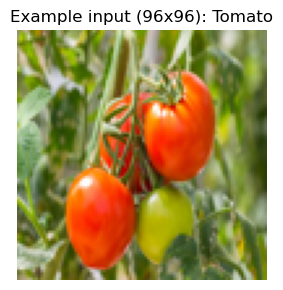

Saved: runs/veggie_mnv2/example_input_96x96.png  (20778 bytes)
Source: mnv2_dataset/val/Tomato/Tomato_1.jpg


In [20]:
# Cell 14: Save one example input image (for model upload / sanity test)
# Pick one val image, resize to IMG_SIZE x IMG_SIZE, save as PNG.

example_cls = 'Tomato'
src_files = sorted((MNV2_DATASET / 'val' / example_cls).glob('*'))
src_path = src_files[0]

example_img = Image.open(src_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
example_path = RUN_DIR / f'example_input_{IMG_SIZE}x{IMG_SIZE}.png'
example_img.save(example_path)

plt.figure(figsize=(3, 3))
plt.imshow(example_img)
plt.title(f'Example input ({IMG_SIZE}x{IMG_SIZE}): {example_cls}')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Saved: {example_path}  ({example_path.stat().st_size} bytes)')
print(f'Source: {src_path}')


## ESP32S3 Deployment Notes

### MobileNetV2 (alpha=0.35, 96x96) vs YOLOv8n-cls
|  | YOLOv8n-cls | MobileNetV2-0.35 |
|---|---|---|
| Parameters | ~1.5M | ~410K |
| TFLite INT8 size | ~1.5 MB | ~450 KB |
| Expected accuracy | Higher | Slightly lower |
| Inference time (ESP32S3) | ~500-2000 ms | ~150-400 ms |
| Tensor arena needed | ~500 KB - 1 MB | ~200-300 KB |

### Input convention
The exported TFLite takes **raw `uint8` / `int8` pixels in [0,255] space** - `preprocess_input` ([-1,1] scaling) is baked into the graph. On the ESP32 side you can feed camera pixels directly after resizing to 96x96, no extra normalization needed.

### Update ESP32 sketch
Copy `model_data.h` and `labels.h` into `esp32_deploy/`, then in the `.ino`:
```cpp
constexpr int kTensorArenaSize = 300 * 1024;  // ~300KB covers MobileNetV2-0.35@96
```
This fits in internal SRAM on the XIAO ESP32S3, but if you hit allocation errors fall back to PSRAM:
```cpp
uint8_t* tensor_arena = (uint8_t*)ps_malloc(kTensorArenaSize);
```